In [ ]:
 # gender age 공분산 통해서 회귀분석 돌린다..?
 # 두개의 영향을 보고싶지 않을 때

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (2).csv


In [ ]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv") # 데이터 불러오기
data.head() # 데이터 위에서 5개만 보기

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
column_unique = ['gender', 'hypertension', 'heart_disease',  # unique 값을 보고싶은 열만 변수에 저장
                 'ever_married','work_type', 'Residence_type', 
                 'smoking_status', 'stroke']

In [ ]:
for i in column_unique: # 각 행별로 어떤 값들이 있는지 
    a = data[i].unique()
    print(a)

['Male' 'Female' 'Other']
[0 1]
[1 0]
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['Urban' 'Rural']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
[1 0]


In [ ]:
data.info() # 결측값 확인 / age 실수인것 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# 전처리

## 이상치 
- gender

In [ ]:
data["gender"].value_counts() #  한 개밖에 없어서 제거 결정

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [ ]:
data.loc[data["gender"] == "Other"].index

Int64Index([3116], dtype='int64')

In [ ]:
data = data.drop(data.loc[data["gender"] == "Other"].index, axis=0).copy() # Other 행 삭제

In [ ]:
data["gender"].value_counts() # 지워졌나 확인

Female    2994
Male      2115
Name: gender, dtype: int64

## 결측값
- 흡연 컬럼의 unkown
- bmi 결측값

In [ ]:
data["smoking_status"].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [ ]:
1544/(1892+884+789) * 100 # 결측값 비율 43%

43.30995792426368

In [ ]:
data = data.drop(data.loc[data["smoking_status"]=="Unknown"].index, axis = 0).copy() # Unkown이 있는 행 모두 삭제

In [ ]:
data["smoking_status"].value_counts()

never smoked       1892
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [ ]:
data = data.loc[~data["bmi"].isna()] # bmi가 결측값이 아닌 행들만 가져옴

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3425 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3425 non-null   int64  
 1   gender             3425 non-null   object 
 2   age                3425 non-null   float64
 3   hypertension       3425 non-null   int64  
 4   heart_disease      3425 non-null   int64  
 5   ever_married       3425 non-null   object 
 6   work_type          3425 non-null   object 
 7   Residence_type     3425 non-null   object 
 8   avg_glucose_level  3425 non-null   float64
 9   bmi                3425 non-null   float64
 10  smoking_status     3425 non-null   object 
 11  stroke             3425 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 347.9+ KB


## 자료형 변경
- age 실수 -> 정수

In [ ]:
data = data.astype({"age":int})

In [ ]:
data["age"].dtype

dtype('int64')

## 이진화 / 더미변수
- gender
- ever_married
- Residence_type
- smoking_status
- work_type

In [ ]:
data['gender'] = data['gender'].apply(lambda x: 1 if x=='Male' else 0) # 이진화 
data['ever_married'] = data['ever_married'].apply(lambda x: 1 if x=='Yes' else 0)
data['Residence_type'] = data['Residence_type'].apply(lambda x: 1 if x=='Urban' else 0)

In [ ]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67,0,1,1,Private,1,228.69,36.6,formerly smoked,1
2,31112,1,80,0,1,1,Private,0,105.92,32.5,never smoked,1
3,60182,0,49,0,0,1,Private,1,171.23,34.4,smokes,1
4,1665,0,79,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
5,56669,1,81,0,0,1,Private,1,186.21,29.0,formerly smoked,1


In [ ]:
# 더미변수 만들기
data = pd.get_dummies(data, columns = ['work_type','smoking_status']).copy()


In [ ]:
data.columns = data.columns.str.replace('work_type_', '') # 더미변수로 바꿀 때 고정적으로 붙는 접두어 삭제
data.columns = data.columns.str.replace('smoking_status_', '')


In [ ]:
# id 열은 필요 없으니까 삭제
data = data.drop(columns="id",axis=1)

In [ ]:
# stroke 맨뒤로 보내줌
# col2 열의 위치를 가져옴
col2_idx = data.columns.get_loc('stroke')

# 열 순서를 변경한 새로운 데이터프레임 생성
new_order = list(range(len(data.columns)))
new_order.pop(col2_idx)
new_order.append(col2_idx)
data = data.reindex(columns=data.columns[new_order])

In [ ]:
data.head(3)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
0,1,67,0,1,1,1,228.69,36.6,0,0,1,0,0,1,0,0,1
2,1,80,0,1,1,0,105.92,32.5,0,0,1,0,0,0,1,0,1
3,0,49,0,0,1,1,171.23,34.4,0,0,1,0,0,0,0,1,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3425 entries, 0 to 5108
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3425 non-null   int64  
 1   age                3425 non-null   int64  
 2   hypertension       3425 non-null   int64  
 3   heart_disease      3425 non-null   int64  
 4   ever_married       3425 non-null   int64  
 5   Residence_type     3425 non-null   int64  
 6   avg_glucose_level  3425 non-null   float64
 7   bmi                3425 non-null   float64
 8   Govt_job           3425 non-null   uint8  
 9   Never_worked       3425 non-null   uint8  
 10  Private            3425 non-null   uint8  
 11  Self-employed      3425 non-null   uint8  
 12  children           3425 non-null   uint8  
 13  formerly smoked    3425 non-null   uint8  
 14  never smoked       3425 non-null   uint8  
 15  smokes             3425 non-null   uint8  
 16  stroke             3425 

## 표준화/정규화

- 정규화 : 데이터 셋 최솟값이 0이 되고, 데이터셋의 최대값 1 분포에 영향x

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3425 entries, 0 to 5108
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3425 non-null   int64  
 1   age                3425 non-null   int64  
 2   hypertension       3425 non-null   int64  
 3   heart_disease      3425 non-null   int64  
 4   ever_married       3425 non-null   int64  
 5   Residence_type     3425 non-null   int64  
 6   avg_glucose_level  3425 non-null   float64
 7   bmi                3425 non-null   float64
 8   Govt_job           3425 non-null   uint8  
 9   Never_worked       3425 non-null   uint8  
 10  Private            3425 non-null   uint8  
 11  Self-employed      3425 non-null   uint8  
 12  children           3425 non-null   uint8  
 13  formerly smoked    3425 non-null   uint8  
 14  never smoked       3425 non-null   uint8  
 15  smokes             3425 non-null   uint8  
 16  stroke             3425 

In [ ]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
scaler = StandardScaler()

# 열들을 표준화
data[["age","avg_glucose_level","bmi"]] = scaler.fit_transform(data[["age","avg_glucose_level","bmi"]])
data.tail()


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
5100,1,1.769352,1,0,1,0,-0.761883,-0.273123,0,0,0,1,0,0,1,0,0
5102,0,0.442900,0,0,1,0,-0.636935,-1.177887,0,0,1,0,0,0,1,0,0
5106,0,1.716294,0,0,1,1,0.354055,1.330779,0,0,0,1,0,0,1,0,0
5107,0,-0.724379,0,0,1,0,-0.530855,0.042174,0,0,0,1,0,0,1,0,0
5108,1,0.124551,0,0,1,0,1.215484,-0.643254,0,0,1,0,0,1,0,0,0


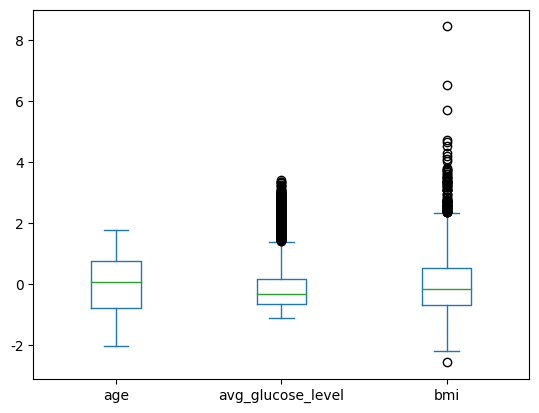

In [ ]:
data[["age","avg_glucose_level","bmi"]].plot.box()
plt.show()

- bmi 값에서 극단적인 값은 제거
- -2.5 보다 작은 값의 bmi는 어떻게 할까?

In [ ]:
# bmi 값이 5보다 큰 3개 행 제거
data = data[data["bmi"]<5]


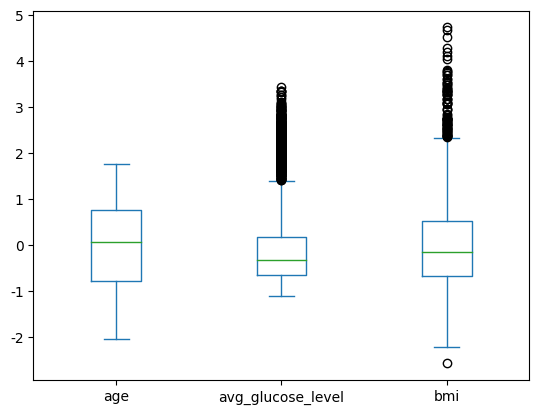

In [ ]:
data[["age","avg_glucose_level","bmi"]].plot.box()
plt.show()

In [ ]:
data.to_csv('stroke_data_0521.csv', index=False)

## feature selection 

독립변수들 간 상관계수 분석

In [ ]:
data_feature_selection = data.drop(columns="stroke",axis=1)
data_feature_selection_int  = data_feature_selection[["age","avg_glucose_level","bmi"]]


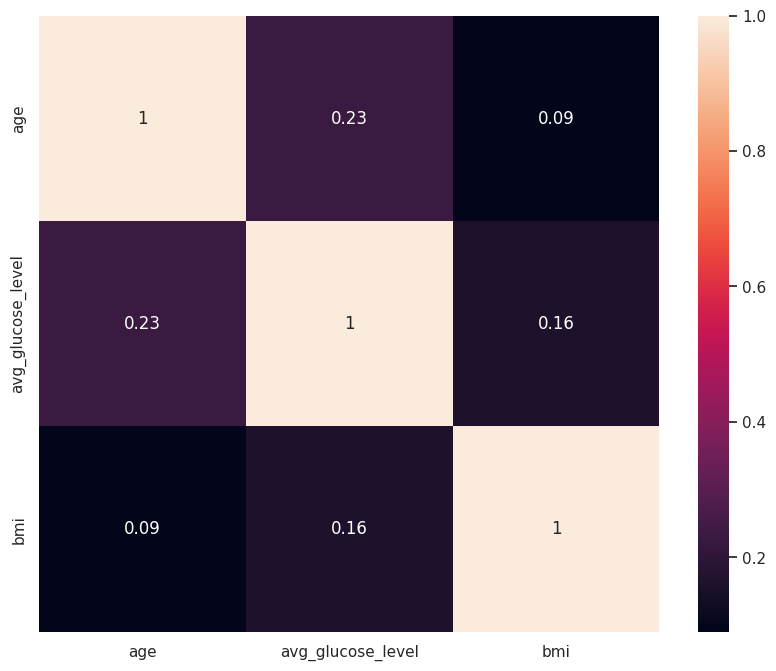

In [ ]:
sns.set(rc={"figure.figsize":(10,8)})
correlation_matrix = data_feature_selection_int.corr().round(2)
sns.heatmap(data=correlation_matrix, annot = True)
plt.show()

더미 변수화 한 범주형 데이터와 연속형 데이터간의 상관계수를 보는게 가능한건가?

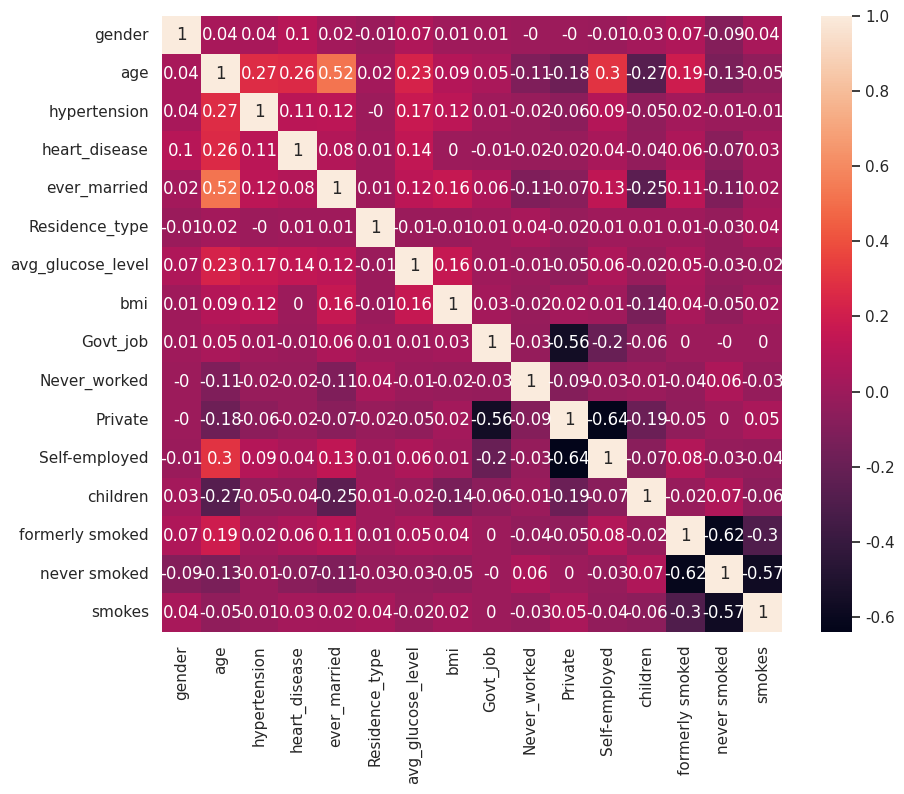

In [ ]:
sns.set(rc={"figure.figsize":(10,8)})
correlation_matrix = data_feature_selection.corr().round(2)
sns.heatmap(data=correlation_matrix, annot = True)
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 상수(intercept) 열 추가
data_feature_selection_int = sm.add_constant(data_feature_selection_int)

# VIF 계산
vif = pd.DataFrame()
vif["Features"] = data_feature_selection_int.columns
vif["VIF"] = [variance_inflation_factor(data_feature_selection_int.values, i) for i in range(data_feature_selection_int.shape[1])]

# 결과 출력
print(vif)

            Features       VIF
0              const  1.000040
1                age  1.060594
2  avg_glucose_level  1.080782
3                bmi  1.029180


In [ ]:

# 상수(intercept) 열 추가
data_feature_selection = sm.add_constant(data_feature_selection)

# VIF 계산
vif = pd.DataFrame()
vif["Features"] = data_feature_selection.columns
vif["VIF"] = [variance_inflation_factor(data_feature_selection.values, i) for i in range(data_feature_selection.shape[1])]

# 결과 출력
print(vif)

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1752: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


             Features           VIF
0               const  0.000000e+00
1              gender  1.024134e+00
2                 age  1.820751e+00
3        hypertension  1.107465e+00
4       heart_disease  1.098323e+00
5        ever_married  1.442059e+00
6      Residence_type  1.004072e+00
7   avg_glucose_level  1.106611e+00
8                 bmi  1.076203e+00
9            Govt_job  1.245100e+08
10       Never_worked  3.314639e+10
11            Private  4.660338e+04
12      Self-employed  8.354350e+07
13           children  1.595842e+09
14    formerly smoked           inf
15       never smoked           inf
16             smokes           inf


## 오버샘플링 후 랜덤포레스트

### SMOTE

In [ ]:
x = data.drop("stroke",axis = 1) #독립변수
y = data["stroke"] # 종속변수

In [ ]:
# train 과 test데이터를 미리나눠 test데이터의 독립성을 유지할 수 있게함
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [ ]:
# 오버 샘플링을 통해 불균형 데이터 처리
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_resampled_smote, y_resampled_smote = smote.fit_resample(x_train,y_train)  # train data에 대해서만 오버샘플링 진행함

# 분포 변화
print("before SMOTE :\n", y.value_counts()) # 기존 뇌졸중 비율 분포
print("\nbefore SMOTE :\n", y_resampled_smote.value_counts()) # 불균형 처리 후 뇌졸중 비율 분포

before SMOTE :
 0    3242
1     180
Name: stroke, dtype: int64

before SMOTE :
 0    2274
1    2274
Name: stroke, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)

# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.9399267399267399
Precision: 0.9178674351585014
Recall: 0.9622356495468278


In [ ]:
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

In [ ]:
# 각 독립 변수의 중요도를 데이터프레임으로 변환하기
df = pd.DataFrame(list(zip(x_train.columns, random_forest.feature_importances_)),
                             columns=["name", "importance"])
df = df.rename(columns={"name":"독립변수"})

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


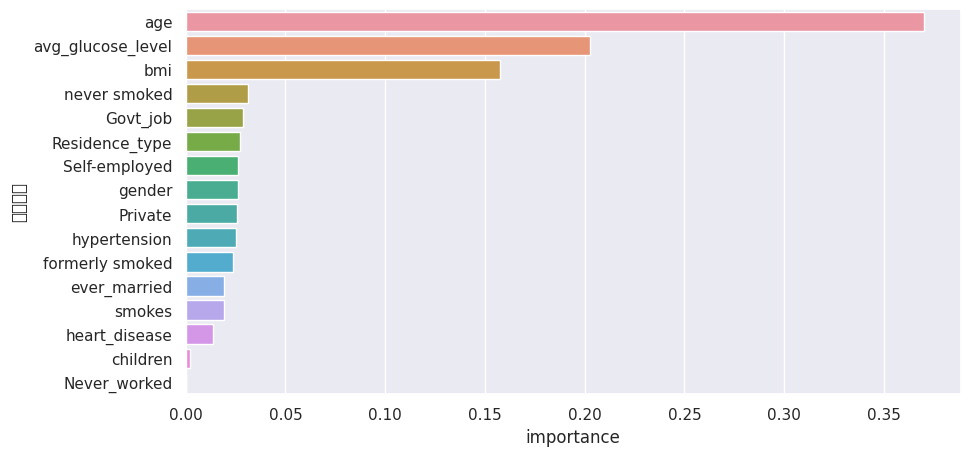

In [ ]:
# 뇌졸중에 가장 영향을 많이주는 독립변수를 순서대로 나열
plt.figure(figsize=(10,5))
sns.barplot(data = df,
            x="importance", y="독립변수",
            orient="h",
            order=df.sort_values(by="importance",ascending=False)["독립변수"])
plt.show()

## 언더샘플링 후 랜덤포레스트
- RandomUnderSampler
- NearMiss
- TomekLinks
- EditedNearestNeighbours
- OneSidedSelection
- Condensed Nearest Neighbor (CNN)

질문
- 모델을 돌릴때마다 성능이 조금이 달라질텐데 모델 평가를 어떻게하고 어떤 모델이 좋을지 어떻게 고를까요?
- precision(정밀도)과 recall(재현율)의 값은 0과 1에 대해서 각각 2개의 평가결과가 나와야 되는거 아닌지 밑에는 하나씩 나왔는데
- knn 모델을 쓰는건 어떤지..

### RandomUnderSampler
- 랜덤으로 데이터 지움

In [ ]:
y.value_counts()

0    3242
1     180
Name: stroke, dtype: int64

In [ ]:
from imblearn.under_sampling import RandomUnderSampler


# 언더샘플링 수행
rus = RandomUnderSampler(random_state=42)
x_resampled_rus, y_resampled_rus = rus.fit_resample(x, y)

y_count = y_resampled_rus.value_counts()

# 언더샘플링된 데이터 확인
print(y_count)

0    180
1    180
Name: stroke, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier


# 최적의 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# 최적의 점수: 0.9067809038252388

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_rus, y_resampled_rus, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.7870370370370371
Precision: 0.7419354838709677
Recall: 0.8679245283018868


In [ ]:
# 각 독립 변수의 중요도를 데이터프레임으로 변환하기
df = pd.DataFrame(list(zip(x_train.columns, random_forest.feature_importances_)),
                             columns=["name", "importance"])
df = df.rename(columns={"name":"독립변수"})

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


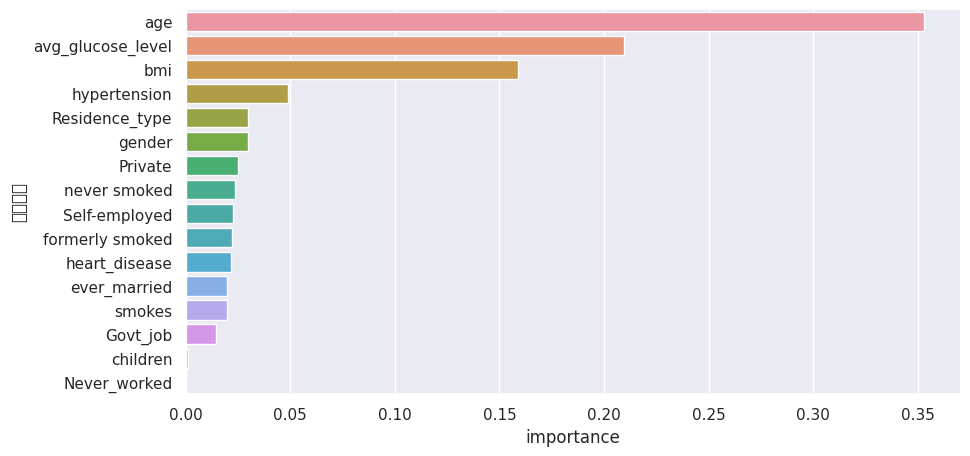

In [ ]:
# 뇌졸중에 가장 영향을 많이주는 독립변수를 순서대로 나열
plt.figure(figsize=(10,5))
sns.barplot(data = df,
            x="importance", y="독립변수",
            orient="h",
            order=df.sort_values(by="importance",ascending=False)["독립변수"])
plt.show()

### TomekLinks
- 두 범주중에 가까운 것들끼리 link 된 후 다수 범주 제거 -> 분류경계에서 데이터가 제거됨

In [ ]:
from imblearn.under_sampling import TomekLinks

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_tl, y_resampled_tl = TomekLinks().fit_resample(x, y)

# 데이터 불균형 해소 효과가 적음
y_resampled_tl.value_counts()

0    3155
1     180
Name: stroke, dtype: int64

In [ ]:
# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_tl, y_resampled_tl, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.938061938061938
Precision: 0.3333333333333333
Recall: 0.01639344262295082


### NearMiss

Nearmiss-1 : Majority class examples with minimum average distance to three closest minority class examples.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.under_sampling import NearMiss
import random

#리스트 
accuracies = []
precisions = []
recalls = []
f1_scores = []
    
# 반복 횟수
num_iterations = 10

for _ in range(num_iterations):
    # 랜덤 시드 설정
    random_seed = random.randint(0, 1000)
    np.random.seed(random_seed)

    # 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
    x_resampled_ns1, y_resampled_ns1 = NearMiss(version=1).fit_resample(x, y)
    
    # train, test 데이터셋 분리
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns1, y_resampled_ns1, test_size=0.3, random_state= random_seed)
    # test_size : test 데이터와 train 데이터의 비율
    # random_state : 매번 결과가 같게 해줌( 시드 설정)

    # 랜덤 포레스트 모델 생성하기
    random_forest = RandomForestClassifier(n_estimators=300, 
                                          min_samples_split = 2,
                                          min_samples_leaf= 1,
                                          random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

    # 모델 훈련하기
    random_forest.fit(x_train, y_train)

    #예측하기
    y_pred = random_forest.predict(x_test)

    #평가 지표를 계산하여 리스트에 추가
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    # 각 시행에서의 값 출력
    print(f"시행 {_+1}")
    print("Accuracy (정확도):", accuracy)
    print("Precision (정밀도):", precision)
    print("Recall (재현율):", recall)
    print("F1-score:", f1)
    print()

# 평균 정확도, 정밀도, 재현율, F1-score 계산
avg_accuracy = sum(accuracies) / num_iterations
avg_precision = sum(precisions) / num_iterations
avg_recall = sum(recalls) / num_iterations
avg_f1 = sum(f1_scores) / num_iterations

# 결과 출력
print("Average Accuracy (평균 정확도):", avg_accuracy)
print("Average Precision (평균 정밀도):", avg_precision)
print("Average Recall (평균 재현율):", avg_recall)
print("Average F1-score (평균 F1-score):", avg_f1)

n_avg_accuracy = avg_accuracy
n_avg_precision = avg_precision
n_avg_recall = avg_recall
n_avg_f1 = avg_f1

시행 1
Accuracy (정확도): 0.7592592592592593
Precision (정밀도): 0.7727272727272727
Recall (재현율): 0.68
F1-score: 0.7234042553191491

시행 2
Accuracy (정확도): 0.7407407407407407
Precision (정밀도): 0.7954545454545454
Recall (재현율): 0.6481481481481481
F1-score: 0.7142857142857143

시행 3
Accuracy (정확도): 0.75
Precision (정밀도): 0.7547169811320755
Recall (재현율): 0.7407407407407407
F1-score: 0.7476635514018692

시행 4
Accuracy (정확도): 0.7592592592592593
Precision (정밀도): 0.8
Recall (재현율): 0.7457627118644068
F1-score: 0.7719298245614035

시행 5
Accuracy (정확도): 0.8055555555555556
Precision (정밀도): 0.9
Recall (재현율): 0.6792452830188679
F1-score: 0.7741935483870968

시행 6
Accuracy (정확도): 0.7592592592592593
Precision (정밀도): 0.8297872340425532
Recall (재현율): 0.6842105263157895
F1-score: 0.7499999999999999

시행 7
Accuracy (정확도): 0.75
Precision (정밀도): 0.6875
Recall (재현율): 0.7333333333333333
F1-score: 0.7096774193548386

시행 8
Accuracy (정확도): 0.7777777777777778
Precision (정밀도): 0.8809523809523809
Recall (재현율): 0.6607142857142857
F1

NearMiss-2: Majority class examples with minimum average distance to three furthest minority class examples.
- 성능 제일 좋음

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.under_sampling import NearMiss
import random

#리스트 
accuracies = []
precisions = []
recalls = []
f1_scores = []
    
# 반복 횟수
num_iterations = 10

for _ in range(num_iterations):
    # 랜덤 시드 설정
    random_seed = random.randint(0, 1000)
    np.random.seed(random_seed)

    # 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
    x_resampled_ns1, y_resampled_ns1 = NearMiss(version=2).fit_resample(x, y)
    
    # train, test 데이터셋 분리
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns1, y_resampled_ns1, test_size=0.3, random_state= random_seed)
    # test_size : test 데이터와 train 데이터의 비율
    # random_state : 매번 결과가 같게 해줌( 시드 설정)

    # 랜덤 포레스트 모델 생성하기
    random_forest = RandomForestClassifier(n_estimators=300, 
                                          min_samples_split = 2,
                                          min_samples_leaf= 1,
                                          random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

    # 모델 훈련하기
    random_forest.fit(x_train, y_train)

    #예측하기
    y_pred = random_forest.predict(x_test)

    #평가 지표를 계산하여 리스트에 추가
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    # 각 시행에서의 값 출력
    print(f"시행 {_+1}")
    print("Accuracy (정확도):", accuracy)
    print("Precision (정밀도):", precision)
    print("Recall (재현율):", recall)
    print("F1-score:", f1)
    print()

# 평균 정확도, 정밀도, 재현율, F1-score 계산
avg_accuracy = sum(accuracies) / num_iterations
avg_precision = sum(precisions) / num_iterations
avg_recall = sum(recalls) / num_iterations
avg_f1 = sum(f1_scores) / num_iterations

# 결과 출력
print("Average Accuracy (평균 정확도):", avg_accuracy)
print("Average Precision (평균 정밀도):", avg_precision)
print("Average Recall (평균 재현율):", avg_recall)
print("Average F1-score (평균 F1-score):", avg_f1)

n_avg_accuracy = avg_accuracy
n_avg_precision = avg_precision
n_avg_recall = avg_recall
n_avg_f1 = avg_f1

시행 1
Accuracy (정확도): 0.8518518518518519
Precision (정밀도): 0.8913043478260869
Recall (재현율): 0.7884615384615384
F1-score: 0.836734693877551

시행 2
Accuracy (정확도): 0.8888888888888888
Precision (정밀도): 0.9411764705882353
Recall (재현율): 0.8421052631578947
F1-score: 0.8888888888888888

시행 3
Accuracy (정확도): 0.8796296296296297
Precision (정밀도): 0.9166666666666666
Recall (재현율): 0.8301886792452831
F1-score: 0.8712871287128713

시행 4
Accuracy (정확도): 0.8240740740740741
Precision (정밀도): 0.8363636363636363
Recall (재현율): 0.8214285714285714
F1-score: 0.8288288288288289

시행 5
Accuracy (정확도): 0.8703703703703703
Precision (정밀도): 0.9019607843137255
Recall (재현율): 0.8363636363636363
F1-score: 0.8679245283018867

시행 6
Accuracy (정확도): 0.8888888888888888
Precision (정밀도): 0.8653846153846154
Recall (재현율): 0.9
F1-score: 0.8823529411764707

시행 7
Accuracy (정확도): 0.8425925925925926
Precision (정밀도): 0.8727272727272727
Recall (재현율): 0.8275862068965517
F1-score: 0.8495575221238938

시행 8
Accuracy (정확도): 0.8425925925925926
Pre

In [ ]:
# 각 독립 변수의 중요도를 데이터프레임으로 변환하기
df = pd.DataFrame(list(zip(x_train.columns, random_forest.feature_importances_)),
                             columns=["name", "importance"])
df = df.rename(columns={"name":"독립변수"})

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


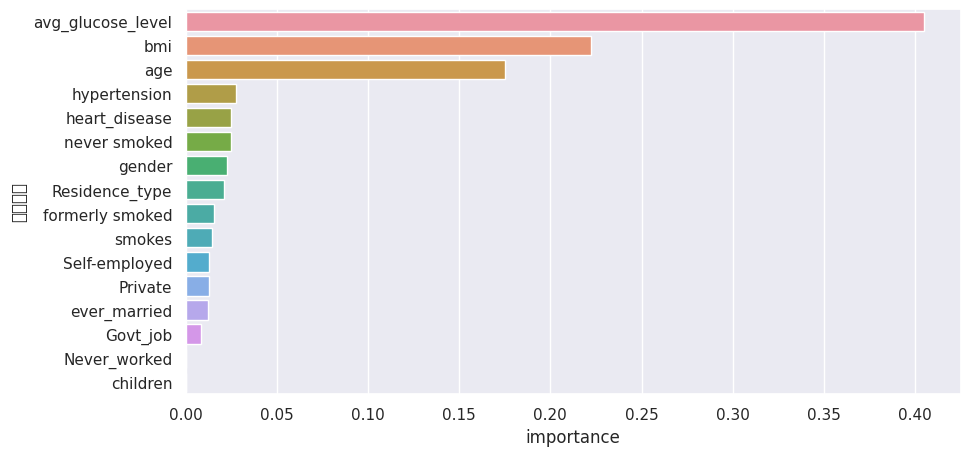

In [ ]:
# 뇌졸중에 가장 영향을 많이주는 독립변수를 순서대로 나열
plt.figure(figsize=(10,5))
sns.barplot(data = df,
            x="importance", y="독립변수",
            orient="h",
            order=df.sort_values(by="importance",ascending=False)["독립변수"])
plt.show()

NearMiss-3: Majority class examples with minimum distance to each minority class example.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.under_sampling import NearMiss
import random

#리스트 
accuracies = []
precisions = []
recalls = []
f1_scores = []
    
# 반복 횟수
num_iterations = 10

for _ in range(num_iterations):
    # 랜덤 시드 설정
    random_seed = random.randint(0, 1000)
    np.random.seed(random_seed)

    # 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
    x_resampled_ns1, y_resampled_ns1 = NearMiss(version=3).fit_resample(x, y)
    
    # train, test 데이터셋 분리
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns1, y_resampled_ns1, test_size=0.3, random_state= random_seed)
    # test_size : test 데이터와 train 데이터의 비율
    # random_state : 매번 결과가 같게 해줌( 시드 설정)

    # 랜덤 포레스트 모델 생성하기
    random_forest = RandomForestClassifier(n_estimators=300, 
                                          min_samples_split = 2,
                                          min_samples_leaf= 1,
                                          random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

    # 모델 훈련하기
    random_forest.fit(x_train, y_train)

    #예측하기
    y_pred = random_forest.predict(x_test)

    #평가 지표를 계산하여 리스트에 추가
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    # 각 시행에서의 값 출력
    print(f"시행 {_+1}")
    print("Accuracy (정확도):", accuracy)
    print("Precision (정밀도):", precision)
    print("Recall (재현율):", recall)
    print("F1-score:", f1)
    print()

# 평균 정확도, 정밀도, 재현율, F1-score 계산
avg_accuracy = sum(accuracies) / num_iterations
avg_precision = sum(precisions) / num_iterations
avg_recall = sum(recalls) / num_iterations
avg_f1 = sum(f1_scores) / num_iterations

# 결과 출력
print("Average Accuracy (평균 정확도):", avg_accuracy)
print("Average Precision (평균 정밀도):", avg_precision)
print("Average Recall (평균 재현율):", avg_recall)
print("Average F1-score (평균 F1-score):", avg_f1)

n_avg_accuracy = avg_accuracy
n_avg_precision = avg_precision
n_avg_recall = avg_recall
n_avg_f1 = avg_f1

시행 1
Accuracy (정확도): 0.6296296296296297
Precision (정밀도): 0.6
Recall (재현율): 0.5510204081632653
F1-score: 0.5744680851063829

시행 2
Accuracy (정확도): 0.5925925925925926
Precision (정밀도): 0.559322033898305
Recall (재현율): 0.6470588235294118
F1-score: 0.6

시행 3
Accuracy (정확도): 0.6851851851851852
Precision (정밀도): 0.7804878048780488
Recall (재현율): 0.5614035087719298
F1-score: 0.653061224489796

시행 4
Accuracy (정확도): 0.6296296296296297
Precision (정밀도): 0.6122448979591837
Recall (재현율): 0.5882352941176471
F1-score: 0.6000000000000001

시행 5
Accuracy (정확도): 0.6018518518518519
Precision (정밀도): 0.6379310344827587
Recall (재현율): 0.6271186440677966
F1-score: 0.6324786324786326

시행 6
Accuracy (정확도): 0.6574074074074074
Precision (정밀도): 0.717948717948718
Recall (재현율): 0.5185185185185185
F1-score: 0.6021505376344085

시행 7
Accuracy (정확도): 0.5092592592592593
Precision (정밀도): 0.4909090909090909
Recall (재현율): 0.5192307692307693
F1-score: 0.5046728971962617

시행 8
Accuracy (정확도): 0.6203703703703703
Precision (정밀도): 0.6

### EditedNearestNeighbours

In [ ]:
from imblearn.under_sampling import EditedNearestNeighbours

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
X_resampled_ens, y_resampled_ens = EditedNearestNeighbours().fit_resample(x, y)

y_resampled_ens.value_counts()

0    2835
1     180
Name: stroke, dtype: int64

### OneSidedSelection

In [ ]:
from imblearn.under_sampling import OneSidedSelection

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_oss, y_resampled_oss = OneSidedSelection().fit_resample(x, y)

y_resampled_oss.value_counts()

0    3120
1     180
Name: stroke, dtype: int64

### CNN

오류

앞으로 해야될 것
1. 어떤 불균형 처리 방법을 선택할건지
2. 어떤 머신러닝 모델을 선택할건지(로지스틱/랜덤포레스트/KNN)
3. 각 변수들 추가 분석